In [11]:
pip install pandas requests matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd

# Load raw delinquency data
raw_delinquency = pd.read_csv("raw_data/delinquency_consumer.csv")

# Display first 10 rows
raw_delinquency.head(10)


,realtime_start,realtime_end,date,value
0,2026-01-19,2026-01-19,1991-01-01,5.26
1,2026-01-19,2026-01-19,1991-04-01,5.48
2,2026-01-19,2026-01-19,1991-07-01,5.35
3,2026-01-19,2026-01-19,1991-10-01,5.32
4,2026-01-19,2026-01-19,1992-01-01,5.27
5,2026-01-19,2026-01-19,1992-04-01,5.10
6,2026-01-19,2026-01-19,1992-07-01,4.98
7,2026-01-19,2026-01-19,1992-10-01,4.69
8,2026-01-19,2026-01-19,1993-01-01,4.60
9,2026-01-19,2026-01-19,1993-04-01,4.46


In [13]:
# Load raw charge-off data
raw_chargeoff = pd.read_csv("raw_data/chargeoff_consumer.csv")

# Display first 10 rows
raw_chargeoff.head(10)


,realtime_start,realtime_end,date,value
0,2026-01-27,2026-01-27,1985-01-01,1.90
1,2026-01-27,2026-01-27,1985-04-01,2.26
2,2026-01-27,2026-01-27,1985-07-01,2.67
3,2026-01-27,2026-01-27,1985-10-01,2.91
4,2026-01-27,2026-01-27,1986-01-01,3.13
5,2026-01-27,2026-01-27,1986-04-01,3.20
6,2026-01-27,2026-01-27,1986-07-01,3.39
7,2026-01-27,2026-01-27,1986-10-01,3.39
8,2026-01-27,2026-01-27,1987-01-01,3.45
9,2026-01-27,2026-01-27,1987-04-01,3.34


In [14]:
import pandas as pd

clean_df = pd.read_csv("clean_data/banking_system_indicators.csv")

clean_df.head(10)


,date,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate
0,1948-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4
1,1948-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.8
2,1948-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
3,1948-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.9
4,1948-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5
5,1948-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.6
6,1948-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.6
7,1948-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.9
8,1948-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.8
9,1948-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7


In [15]:
import requests
import pandas as pd

API_KEY = "df78890f2959f8c083e5256ad0ff3817"

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "DRCCLACBS",   # Delinquency Rate on Consumer Loans
    "api_key": API_KEY,
    "file_type": "json"
}

response = requests.get(url, params=params)

data = response.json()
df = pd.DataFrame(data["observations"])

df.head()


,realtime_start,realtime_end,date,value
0,2026-02-25,2026-02-25,1991-01-01,5.26
1,2026-02-25,2026-02-25,1991-04-01,5.48
2,2026-02-25,2026-02-25,1991-07-01,5.35
3,2026-02-25,2026-02-25,1991-10-01,5.32
4,2026-02-25,2026-02-25,1992-01-01,5.27


In [16]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Convert value column to numeric (force errors to NaN)
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Check for missing values
df.isna().sum()


realtime_start    0
realtime_end      0
date              0
value             0
dtype: int64

In [17]:
df.tail()


,realtime_start,realtime_end,date,value
135,2026-02-25,2026-02-25,2024-10-01,3.08
136,2026-02-25,2026-02-25,2025-01-01,3.06
137,2026-02-25,2026-02-25,2025-04-01,3.04
138,2026-02-25,2026-02-25,2025-07-01,2.98
139,2026-02-25,2026-02-25,2025-10-01,2.94


In [18]:
df.to_csv("raw_delinquency_consumer.csv", index=False)


In [19]:
def fetch_fred_series(series_id):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    data = response.json()
    df = pd.DataFrame(data["observations"])
    
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    return df


In [20]:
df_chargeoff = fetch_fred_series("CORCCACBS")
df_chargeoff.head()


,realtime_start,realtime_end,date,value
0,2026-03-01,2026-03-01,1985-01-01,1.90
1,2026-03-01,2026-03-01,1985-04-01,2.26
2,2026-03-01,2026-03-01,1985-07-01,2.67
3,2026-03-01,2026-03-01,1985-10-01,2.91
4,2026-03-01,2026-03-01,1986-01-01,3.13


In [21]:
df_chargeoff.to_csv("raw_chargeoff_consumer.csv", index=False)


In [22]:
fred_series = {
    "delinquency_consumer": "DRCCLACBS",
    "chargeoff_consumer": "CORCCACBS",
    "delinquency_business": "DRCLACBS",
    "total_bank_credit": "TOTBKCR",
    "federal_funds_rate": "FEDFUNDS",
    "treasury_10y": "DGS10",
    "treasury_2y": "DGS2",
    "financial_stress_index": "STLFSI4",
    "unemployment_rate": "UNRATE"
}


In [23]:
import os
os.makedirs("raw_data", exist_ok=True)
os.makedirs("clean_data", exist_ok=True)


In [24]:
raw_datasets = {}

for name, series_id in fred_series.items():
    print(f"Fetching {name} ({series_id})...")
    
    df_temp = fetch_fred_series(series_id)
    
    # Save raw version
    df_temp.to_csv(f"raw_data/{name}.csv", index=False)
    
    raw_datasets[name] = df_temp
    
    print(f"Saved raw_data/{name}.csv")


Fetching delinquency_consumer (DRCCLACBS)...
Saved raw_data/delinquency_consumer.csv
Fetching chargeoff_consumer (CORCCACBS)...
Saved raw_data/chargeoff_consumer.csv
Fetching delinquency_business (DRCLACBS)...
Saved raw_data/delinquency_business.csv
Fetching total_bank_credit (TOTBKCR)...
Saved raw_data/total_bank_credit.csv
Fetching federal_funds_rate (FEDFUNDS)...
Saved raw_data/federal_funds_rate.csv
Fetching treasury_10y (DGS10)...
Saved raw_data/treasury_10y.csv
Fetching treasury_2y (DGS2)...
Saved raw_data/treasury_2y.csv
Fetching financial_stress_index (STLFSI4)...
Saved raw_data/financial_stress_index.csv
Fetching unemployment_rate (UNRATE)...
Saved raw_data/unemployment_rate.csv


In [25]:
merged_df = None

for name, df_temp in raw_datasets.items():
    df_temp = df_temp[["date", "value"]].rename(columns={"value": name})
    
    if merged_df is None:
        merged_df = df_temp
    else:
        merged_df = pd.merge(merged_df, df_temp, on="date", how="outer")


In [26]:
merged_df = merged_df.sort_values("date").reset_index(drop=True)

merged_df.head()
merged_df.tail()


,date,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate
17121,2026-02-20,NaN,NaN,NaN,NaN,NaN,4.08,3.48,-0.5981,NaN
17122,2026-02-23,NaN,NaN,NaN,NaN,NaN,4.03,3.43,NaN,NaN
17123,2026-02-24,NaN,NaN,NaN,NaN,NaN,4.04,3.43,NaN,NaN
17124,2026-02-25,NaN,NaN,NaN,NaN,NaN,4.05,3.45,NaN,NaN
17125,2026-02-26,NaN,NaN,NaN,NaN,NaN,4.02,3.42,NaN,NaN


In [27]:
merged_df.isna().sum()


date                          0
delinquency_consumer      16986
chargeoff_consumer        16962
delinquency_business      16970
total_bank_credit         14353
federal_funds_rate        16267
treasury_10y               1104
treasury_2y                4696
financial_stress_index    15448
unemployment_rate         16190
dtype: int64

In [28]:
merged_df.to_csv("clean_data/banking_system_indicators.csv", index=False)


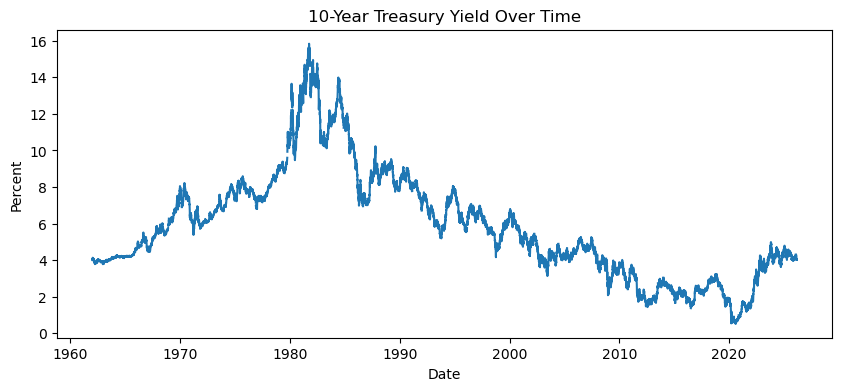

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["treasury_10y"])
plt.title("10-Year Treasury Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


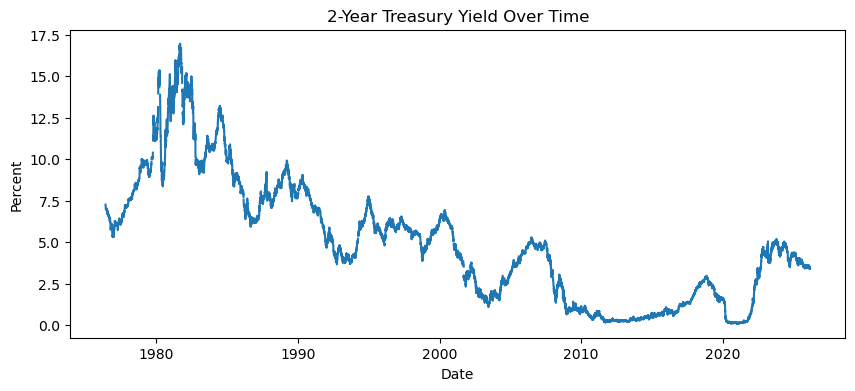

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["treasury_2y"])
plt.title("2-Year Treasury Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


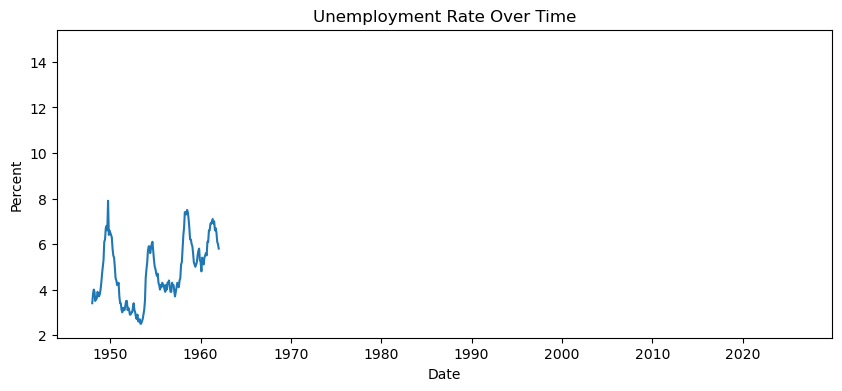

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["unemployment_rate"])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


In [32]:

df_delinquency = pd.read_csv("raw_data/delinquency_consumer.csv")
df_delinquency["date"] = pd.to_datetime(df_delinquency["date"])


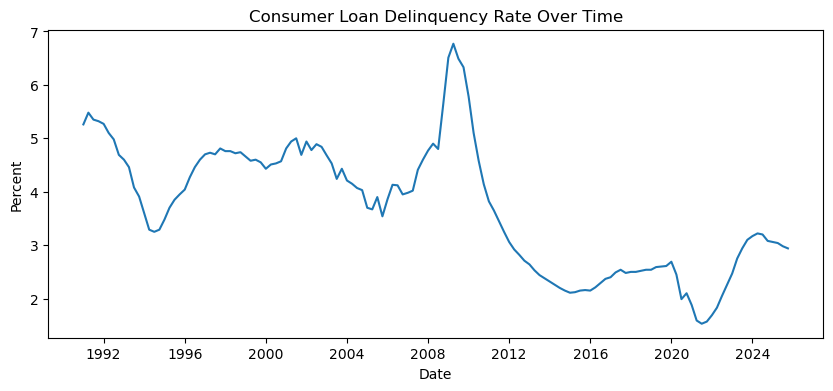

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(df_delinquency["date"], df_delinquency["value"])
plt.title("Consumer Loan Delinquency Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


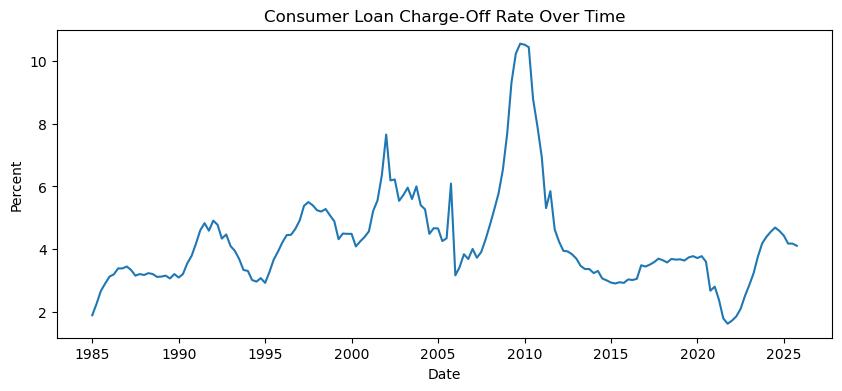

In [34]:
df_chargeoff = pd.read_csv("raw_data/chargeoff_consumer.csv")
df_chargeoff["date"] = pd.to_datetime(df_chargeoff["date"])

plt.figure(figsize=(10, 4))
plt.plot(df_chargeoff["date"], df_chargeoff["value"])
plt.title("Consumer Loan Charge-Off Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.show()


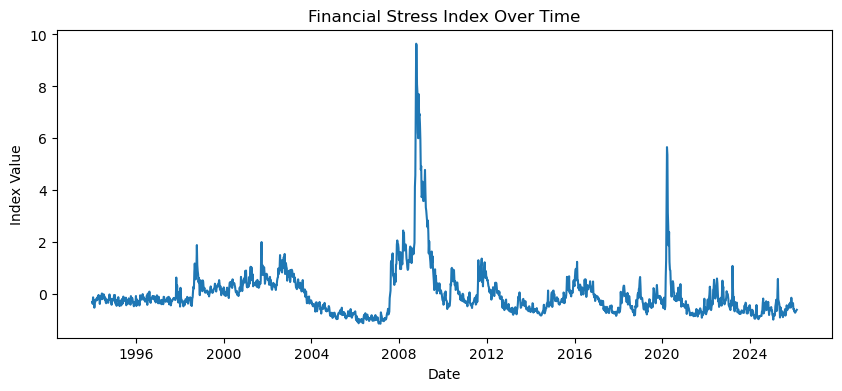

In [35]:
df_stress = pd.read_csv("raw_data/financial_stress_index.csv")
df_stress["date"] = pd.to_datetime(df_stress["date"])

plt.figure(figsize=(10, 4))
plt.plot(df_stress["date"], df_stress["value"])
plt.title("Financial Stress Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()


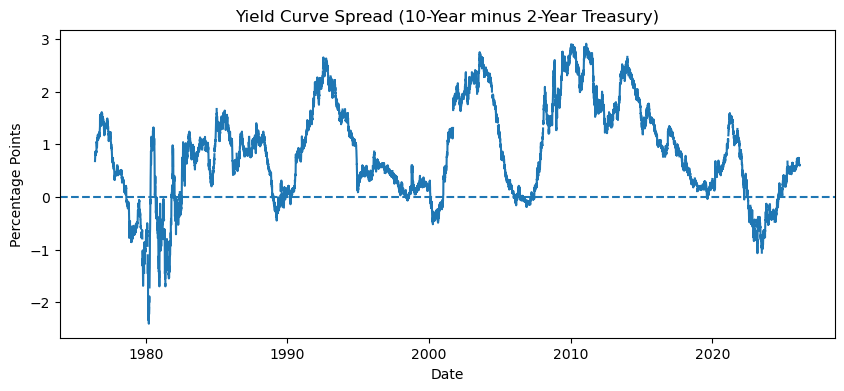

In [36]:
merged_df["yield_spread"] = merged_df["treasury_10y"] - merged_df["treasury_2y"]
plt.figure(figsize=(10, 4))
plt.plot(merged_df["date"], merged_df["yield_spread"])
plt.axhline(0, linestyle="--")
plt.title("Yield Curve Spread (10-Year minus 2-Year Treasury)")
plt.xlabel("Date")
plt.ylabel("Percentage Points")
plt.show()


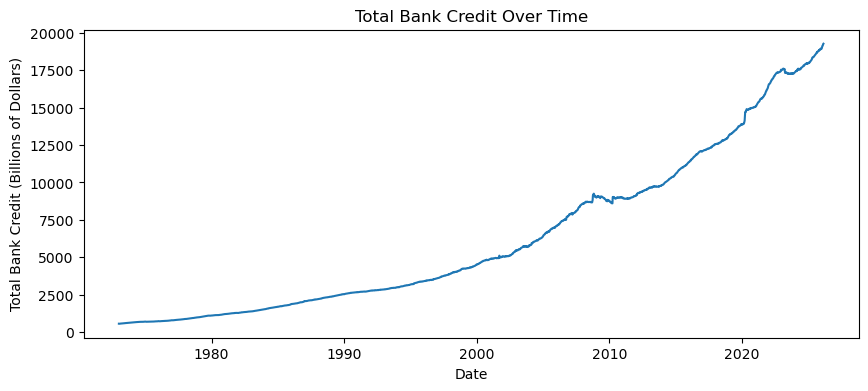

In [37]:
df_credit = pd.read_csv("raw_data/total_bank_credit.csv")
df_credit["date"] = pd.to_datetime(df_credit["date"])
plt.figure(figsize=(10, 4))
plt.plot(df_credit["date"], df_credit["value"])
plt.title("Total Bank Credit Over Time")
plt.xlabel("Date")
plt.ylabel("Total Bank Credit (Billions of Dollars)")
plt.show()


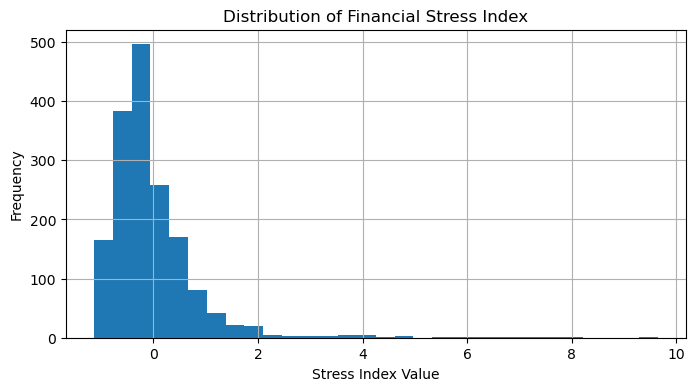

In [38]:
plt.figure(figsize=(8, 4))
merged_df["financial_stress_index"].dropna().hist(bins=30)
plt.title("Distribution of Financial Stress Index")
plt.xlabel("Stress Index Value")
plt.ylabel("Frequency")
plt.show()


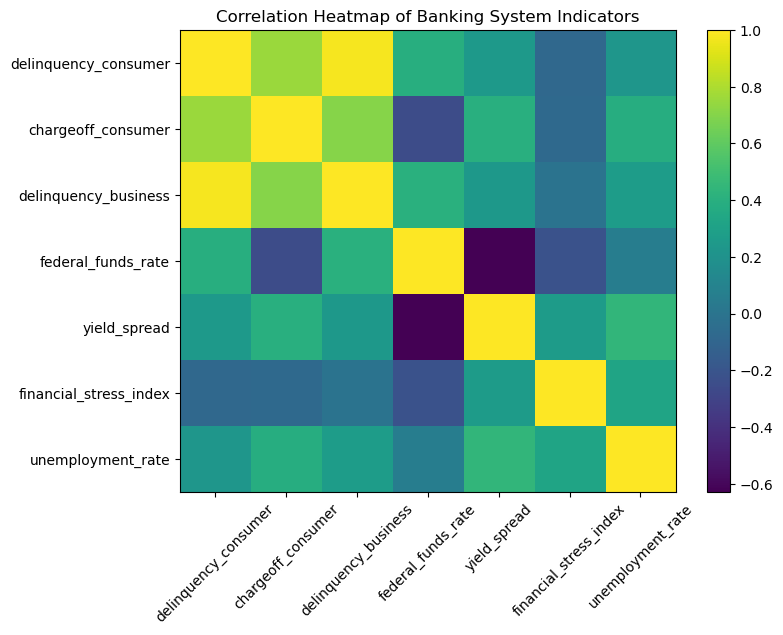

In [39]:
corr_df = merged_df[[
    "delinquency_consumer",
    "chargeoff_consumer",
    "delinquency_business",
    "federal_funds_rate",
    "yield_spread",
    "financial_stress_index",
    "unemployment_rate"
]]
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Banking System Indicators")
plt.show()



In [40]:
#***********************************************************************************************************************

In [41]:
#Module 2

In [42]:
import pandas as pd
import numpy as np

df = merged_df.copy()

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df = df.fillna(method="ffill").dropna()

print(df.isna().sum())

date                      0
delinquency_consumer      0
chargeoff_consumer        0
delinquency_business      0
total_bank_credit         0
federal_funds_rate        0
treasury_10y              0
treasury_2y               0
financial_stress_index    0
unemployment_rate         0
yield_spread              0
dtype: int64


C:\Users\Sreek\AppData\Local\Temp\ipykernel_33004\2576778868.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").dropna()


In [77]:
# Remove date column for modeling
numeric_df = df.drop(columns=["date"])

print("Columns used for modeling:")
print(numeric_df.columns)

Columns used for modeling:
Index(['delinquency_consumer', 'chargeoff_consumer', 'delinquency_business',
       'total_bank_credit', 'federal_funds_rate', 'treasury_10y',
       'treasury_2y', 'financial_stress_index', 'unemployment_rate',
       'yield_spread'],
      dtype='object')


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)

scaled_df.head()

,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate,yield_spread
0,0.279868,-0.663354,0.059555,-1.367666,0.157762,1.182935,0.631404,-0.294996,0.541123,0.685782
1,0.013820,-0.681020,-0.076634,-1.367666,0.198270,1.182935,0.631404,-0.294996,0.597311,0.685782
2,0.013820,-0.681020,-0.076634,-1.367666,0.198270,1.237210,0.655095,-0.294996,0.597311,0.729395
3,0.013820,-0.681020,-0.076634,-1.367666,0.198270,1.213088,0.650357,-0.294996,0.597311,0.696685
4,0.013820,-0.681020,-0.076634,-1.364665,0.198270,1.225149,0.659833,-0.294996,0.597311,0.696685


In [81]:
from sklearn.decomposition import PCA

# PCA 2 Components
pca_2 = PCA(n_components=2)
pca_2_components = pca_2.fit_transform(scaled_data)

# PCA 3 Components
pca_3 = PCA(n_components=3)
pca_3_components = pca_3.fit_transform(scaled_data)

print("Explained Variance (3 Components):")
print(pca_3.explained_variance_ratio_)

print("Cumulative Variance:")
print(np.cumsum(pca_3.explained_variance_ratio_))

Explained Variance (3 Components):
[0.41800057 0.3643061  0.08868148]
Cumulative Variance:
[0.41800057 0.78230667 0.87098815]


In [83]:
pca_full = PCA()
pca_full.fit(scaled_data)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 95% variance:", components_95)

Components needed for 95% variance: 5


In [85]:
eigenvalues = pca_full.explained_variance_

print("Top 3 Eigenvalues:")
print(eigenvalues[:3])

Top 3 Eigenvalues:
[4.18049751 3.64348968 0.88691914]


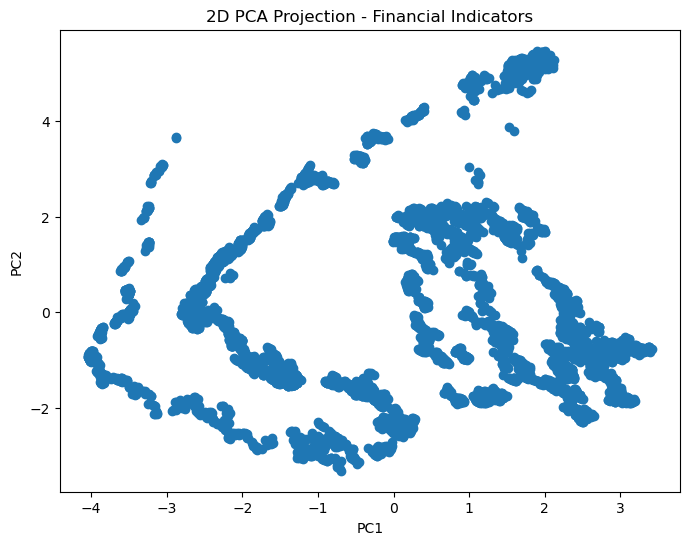

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_2_components[:,0], pca_2_components[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection - Financial Indicators")
plt.show()

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores[k] = score

print("Silhouette Scores:")
print(silhouette_scores)

# Top 3 k values
optimal_ks = sorted(silhouette_scores, key=silhouette_scores.get, reverse=True)[:3]

print("Top 3 optimal k values:", optimal_ks)


Silhouette Scores:
{2: 0.35444644781495566, 3: 0.4090391370924833, 4: 0.4096489668657839, 5: 0.34740588958690344, 6: 0.3624045507504164, 7: 0.3870769857273947, 8: 0.40346998745482626, 9: 0.43066891982961375}
Top 3 optimal k values: [9, 4, 3]


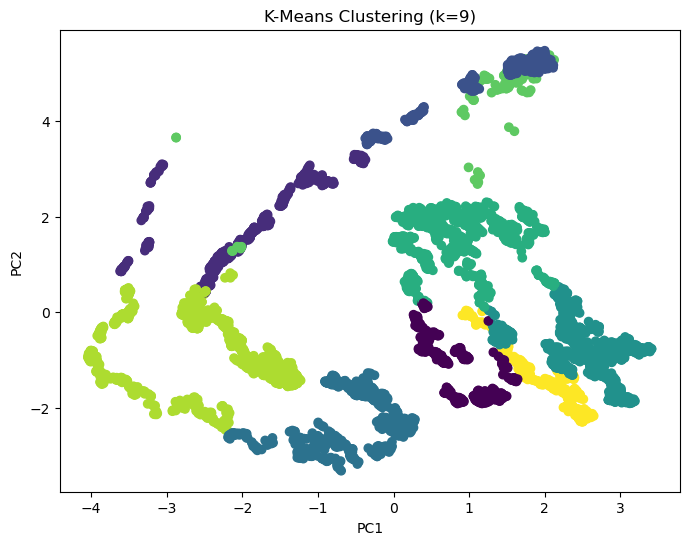

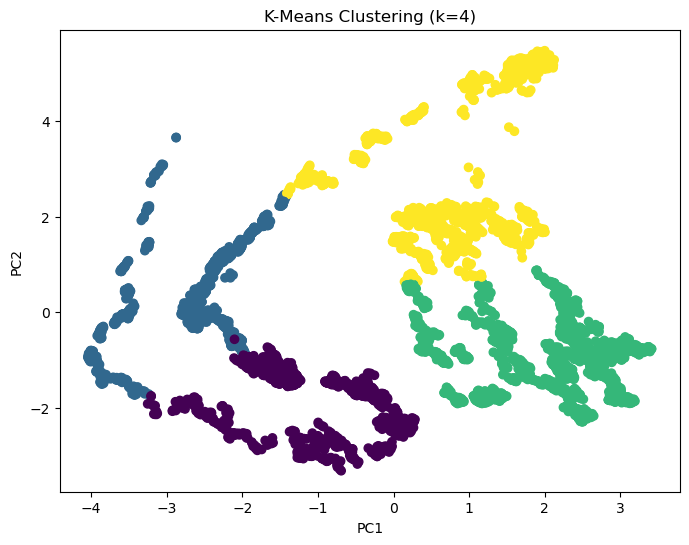

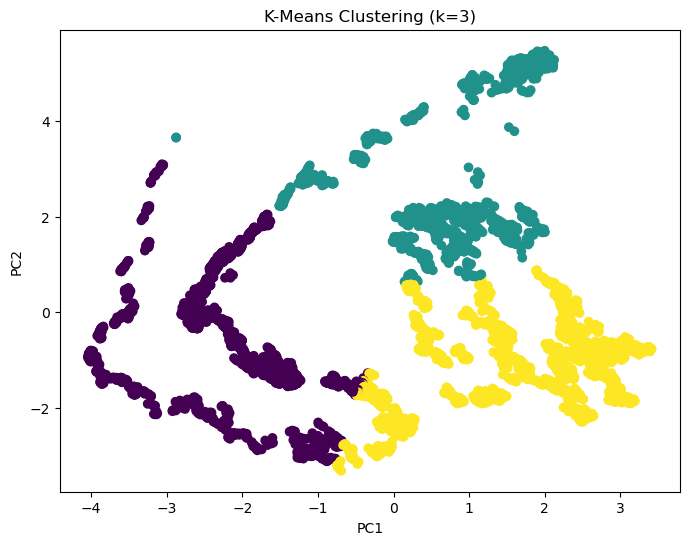

In [91]:
for k in optimal_ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    plt.figure(figsize=(8,6))
    plt.scatter(pca_2_components[:,0], pca_2_components[:,1], c=labels)
    plt.title(f"K-Means Clustering (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

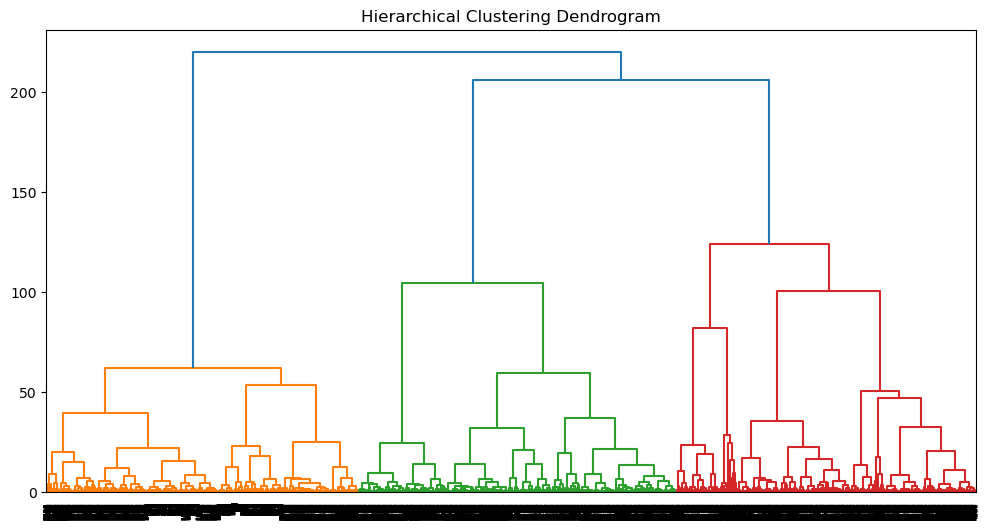

In [93]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

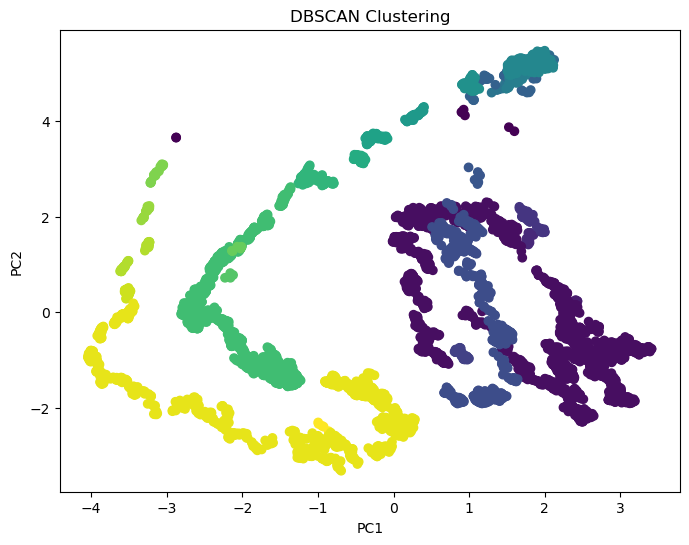

Unique DBSCAN clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25]


In [95]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.7, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_2_components[:,0], pca_2_components[:,1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Unique DBSCAN clusters:", np.unique(db_labels))

In [97]:
binned_df = numeric_df.copy()

for col in binned_df.columns:
    binned_df[col] = pd.qcut(binned_df[col], q=3, labels=["Low", "Medium", "High"])

binned_df.head()

,delinquency_consumer,chargeoff_consumer,delinquency_business,total_bank_credit,federal_funds_rate,treasury_10y,treasury_2y,financial_stress_index,unemployment_rate,yield_spread
8626,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8627,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8628,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8629,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High
8630,Medium,Low,Medium,Low,Medium,High,High,Medium,High,High


In [99]:
transactions = binned_df.apply(
    lambda row: [f"{col}_{val}" for col, val in row.items()],
    axis=1
)

In [101]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
arm_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(arm_df, min_support=0.15, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

top_support = rules.sort_values(by="support", ascending=False).head(15)
top_confidence = rules.sort_values(by="confidence", ascending=False).head(15)
top_lift = rules.sort_values(by="lift", ascending=False).head(15)

print("Top 15 by Support")
print(top_support)

print("Top 15 by Confidence")
print(top_confidence)

print("Top 15 by Lift")
print(top_lift)

Top 15 by Support
                       antecedents                    consequents  \
52      (delinquency_business_Low)     (delinquency_consumer_Low)   
53      (delinquency_consumer_Low)     (delinquency_business_Low)   
114              (treasury_2y_Low)       (federal_funds_rate_Low)   
115       (federal_funds_rate_Low)              (treasury_2y_Low)   
65   (delinquency_business_Medium)  (delinquency_consumer_Medium)   
64   (delinquency_consumer_Medium)  (delinquency_business_Medium)   
41     (delinquency_consumer_High)    (delinquency_business_High)   
40     (delinquency_business_High)    (delinquency_consumer_High)   
105      (federal_funds_rate_High)             (treasury_2y_High)   
104             (treasury_2y_High)      (federal_funds_rate_High)   
122    (federal_funds_rate_Medium)           (treasury_2y_Medium)   
123           (treasury_2y_Medium)    (federal_funds_rate_Medium)   
87              (treasury_10y_Low)     (delinquency_consumer_Low)   
86      (delinqu

In [103]:
top_support[["antecedents","consequents","support","confidence","lift"]]

,antecedents,consequents,support,confidence,lift
52,(delinquency_business_Low),(delinquency_consumer_Low),0.326353,0.976761,2.922374
53,(delinquency_consumer_Low),(delinquency_business_Low),0.326353,0.976417,2.922374
114,(treasury_2y_Low),(federal_funds_rate_Low),0.322941,0.967230,2.895900
115,(federal_funds_rate_Low),(treasury_2y_Low),0.322941,0.966890,2.895900
65,(delinquency_business_Medium),(delinquency_consumer_Medium),0.307765,0.907388,2.678985
64,(delinquency_consumer_Medium),(delinquency_business_Medium),0.307765,0.908649,2.678985
41,(delinquency_consumer_High),(delinquency_business_High),0.303529,0.928058,2.840651
40,(delinquency_business_High),(delinquency_consumer_High),0.303529,0.929060,2.840651
105,(federal_funds_rate_High),(treasury_2y_High),0.295412,0.905191,2.718772
104,(treasury_2y_High),(federal_funds_rate_High),0.295412,0.887279,2.718772
